In [22]:
import importlib
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# adjust path
path_to_hkpt = '../'
import sys
sys.path.append(path_to_hkpt)

import hk_parallel_transport as hkpt
hkpt = importlib.reload(hkpt)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})


In [26]:
# Direct cone experiment: sample exact Gaussian clouds in the cone's Euclidean sector chart.
n_1_cone = 300
n_2_cone = 300
n_3_cone = 300

cone_sector_window = (-0.9, 0.9)

def cone_to_sector_xy(cone_measure):
    theta = cone_measure.samples[:, 0]
    return np.column_stack([
        cone_measure.radii * np.cos(theta),
        cone_measure.radii * np.sin(theta),
    ])

def sample_sector_gaussian(n, mean_angle, mean_radius, covariance, angle_window=cone_sector_window, min_radius=0.2):
    mean_xy = np.array([
        mean_radius * np.cos(mean_angle),
        mean_radius * np.sin(mean_angle),
    ])
    accepted = []
    n_accepted = 0
    batch_size = max(4 * n, 1000)
    while n_accepted < n:
        batch_xy = np.random.multivariate_normal(mean_xy, covariance, size=batch_size)
        batch_radii = np.linalg.norm(batch_xy, axis=1)
        batch_angles = np.arctan2(batch_xy[:, 1], batch_xy[:, 0])
        keep = (
            (batch_radii >= min_radius)
            & (batch_angles >= angle_window[0])
            & (batch_angles <= angle_window[1])
        )
        if np.any(keep):
            accepted.append(batch_xy[keep])
            n_accepted += int(np.sum(keep))
    xy = np.vstack(accepted)[:n]
    radii = np.linalg.norm(xy, axis=1)
    angles = np.arctan2(xy[:, 1], xy[:, 0])
    return hkpt.ConeMeasure(angles[:, None], radii, np.ones(n) / n)

sector_covariance = np.array([[0.010, 0.002], [0.002, 0.006]])

lambda1_cone = sample_sector_gaussian(n_1_cone, -0.40, 1.55, sector_covariance)
lambda2_cone = sample_sector_gaussian(n_2_cone, 0.00, 0.95, sector_covariance)
lambda3_cone = sample_sector_gaussian(n_3_cone, 0.42, 1.15, sector_covariance)

tangent_23_cone = hkpt.cone_logarithmic_map(
    lambda2_cone,
    lambda3_cone,
    approximation_mode='argmax',
)

N_cone = 5
lambda_list_cone, step_tangents_cone = hkpt.cone_wasserstein_geodesic(
    lambda2_cone,
    lambda1_cone,
    N_cone,
    approximation_mode='argmax',
)

transported_cone_tangent, cone_pt_debug = hkpt.cone_wasserstein_parallel_transport(
    lambda_list_cone,
    step_tangents_cone,
    tangent_23_cone,
    step_size=1.0 / N_cone,
    alignment_tol=1e-8,
    return_path=True,
    show_progress=False,
)

final_lambda_cone = lambda_list_cone[-1]
lambda3_at_lambda1_cone = hkpt.cone_exponential_map(
    final_lambda_cone,
    transported_cone_tangent,
    t=1.0,
    aggregate=False,
)


In [27]:
# Numerical diagnostics for the direct cone experiment.
def cone_summary(cone_measure):
    w = cone_measure.weights / np.sum(cone_measure.weights)
    angle_mean = np.sum(cone_measure.samples[:, 0] * w)
    radius_mean = np.sum(cone_measure.radii * w)
    angle_var = np.sum(w * (cone_measure.samples[:, 0] - angle_mean) ** 2)
    radius_var = np.sum(w * (cone_measure.radii - radius_mean) ** 2)
    return angle_mean, radius_mean, angle_var, radius_var

for label, measure in [
    ('lambda1 (transport endpoint)', lambda1_cone),
    ('lambda2 (tangent basepoint)', lambda2_cone),
    ('lambda3 (target of source log)', lambda3_cone),
    ('exp_{lambda1}(PT_{lambda2 -> lambda1}(log_{lambda2}(lambda3)))', lambda3_at_lambda1_cone),
]:
    angle_mean, radius_mean, angle_var, radius_var = cone_summary(measure)
    print(
        f"{label}: total mass = {np.sum(measure.weights):.6f}, "
        f"mean angle = {angle_mean:.6f}, mean radius = {radius_mean:.6f}, "
        f"var(angle) = {angle_var:.6f}, var(radius) = {radius_var:.6f}"
    )

cone_endpoint_error = np.max(
    np.abs(cone_pt_debug['mapped_lambda_path'][-1].samples[:, 0] - final_lambda_cone.samples[:, 0])
)
print(f"Max deterministic cone-map alignment error on final step: {cone_endpoint_error:.6e}")
print(f"Cone tangent path length: {len(cone_pt_debug['tangent_path'])}")


lambda1: total mass = 1.000000, mean angle = -0.397692, mean radius = 1.550962, var(angle) = 0.003638, var(radius) = 0.007379
lambda2: total mass = 1.000000, mean angle = -0.003408, mean radius = 0.949283, var(angle) = 0.006918, var(radius) = 0.011068
lambda3: total mass = 1.000000, mean angle = 0.416546, mean radius = 1.146497, var(angle) = 0.003921, var(radius) = 0.009815
transported exp image: total mass = 1.000000, mean angle = -0.088581, mean radius = 1.536515, var(angle) = 0.003066, var(radius) = 0.007314
Max deterministic cone-map alignment error on final step: 2.775558e-17
Cone tangent path length: 6


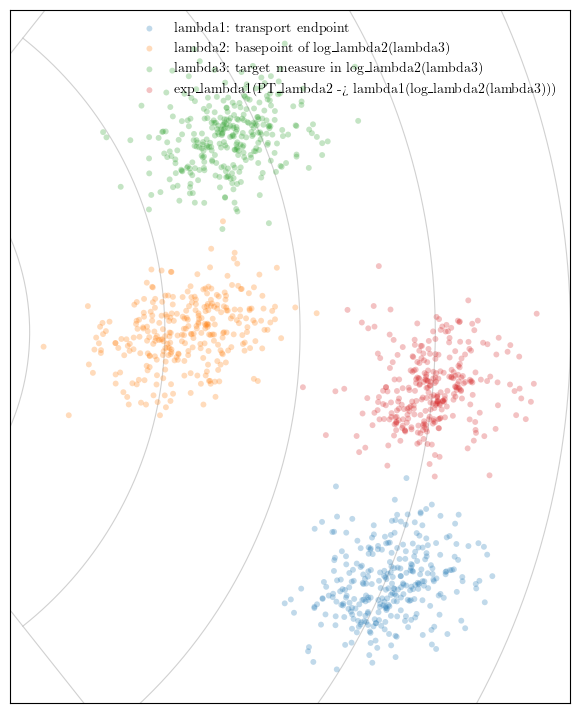

In [29]:
# Plot all cone Gaussians together in the Euclidean sector chart.
def draw_sector_grid(ax, angle_window, radial_levels, color='#bdbdbd'):
    theta = np.linspace(angle_window[0], angle_window[1], 400)
    max_radius = radial_levels[-1]
    for radius in radial_levels:
        ax.plot(radius * np.cos(theta), radius * np.sin(theta), color=color, lw=0.8, alpha=0.7, zorder=0)
    for angle in angle_window:
        ax.plot([0.0, max_radius * np.cos(angle)], [0.0, max_radius * np.sin(angle)], color=color, lw=0.8, alpha=0.7, zorder=0)

def plot_cone_measure_sector(ax, cone_measure, label, color):
    xy = cone_to_sector_xy(cone_measure)
    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        s=18,
        alpha=0.28,
        c=color,
        edgecolors='none',
        label=label,
        zorder=2,
    )

cone_measures = [
    (lambda1_cone, 'lambda1: transport endpoint', '#1f77b4'),
    (lambda2_cone, 'lambda2: basepoint of log_{lambda2}(lambda3)', '#ff7f0e'),
    (lambda3_cone, 'lambda3: target measure in log_{lambda2}(lambda3)', '#2ca02c'),
    (lambda3_at_lambda1_cone, 'exp_{lambda1}(PT_{lambda2 -> lambda1}(log_{lambda2}(lambda3)))', '#d62728'),
]

all_xy = np.vstack([cone_to_sector_xy(measure) for measure, _, _ in cone_measures])
all_radii = np.concatenate([measure.radii for measure, _, _ in cone_measures])
padding = 0.08
x_limits = (all_xy[:, 0].min() - padding, all_xy[:, 0].max() + padding)
y_limits = (all_xy[:, 1].min() - padding, all_xy[:, 1].max() + padding)
max_radius = all_radii.max() + padding
radial_levels = np.linspace(0.25, max_radius, 6)

fig, ax = plt.subplots(figsize=(9, 9))
draw_sector_grid(ax, cone_sector_window, radial_levels)
for measure, title, color in cone_measures:
    plot_cone_measure_sector(ax, measure, title, color)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(x_limits)
ax.set_ylim(y_limits)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(frameon=False, loc='upper right')
plt.show()
